# Predicting Passenger Survival on the Titanic Using Machine Learning 🚢

**1. Importing packages & loading data**

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**2. Understanding the data**

In [182]:
# --- 2. Understanding the data ---

print("📋 Dataset Information:")
print("-" * 50)
print(f"Total passengers: {len(train_df)}")
print(f"Features: {len(train_df.columns)}")
print(f"Missing values: {train_df.isnull().sum().sum()}")
print(f"Survived: {train_df['Survived'].sum()} ({train_df['Survived'].mean()*100:.1f}%)")
print(f"Died: {len(train_df) - train_df['Survived'].sum()} ({(1-train_df['Survived'].mean())*100:.1f}%)")
print("-" * 50)


📋 Dataset Information:
--------------------------------------------------
Total passengers: 891
Features: 12
Missing values: 866
Survived: 342 (38.4%)
Died: 549 (61.6%)
--------------------------------------------------


In [183]:
print("\n📋 Column Descriptions:")
descriptions = {
    'PassengerId': 'Unique ID for each passenger',
    'Survived': 'Survival (0 = No, 1 = Yes)',
    'Pclass': 'Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)',
    'Name': 'Passenger name',
    'Sex': 'Gender',
    'Age': 'Age in years',
    'SibSp': '# of siblings/spouses aboard',
    'Parch': '# of parents/children aboard',
    'Ticket': 'Ticket number',
    'Fare': 'Passenger fare',
    'Cabin': 'Cabin number',
    'Embarked': 'Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)'
}

for col, desc in descriptions.items():
    if col in train_df.columns:
        print(f"  • {col}: {desc}")


📋 Column Descriptions:
  • PassengerId: Unique ID for each passenger
  • Survived: Survival (0 = No, 1 = Yes)
  • Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
  • Name: Passenger name
  • Sex: Gender
  • Age: Age in years
  • SibSp: # of siblings/spouses aboard
  • Parch: # of parents/children aboard
  • Ticket: Ticket number
  • Fare: Passenger fare
  • Cabin: Cabin number
  • Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


**3a. Data Cleaning - Analysis**

Missing Values in Training Data:
          Missing Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467



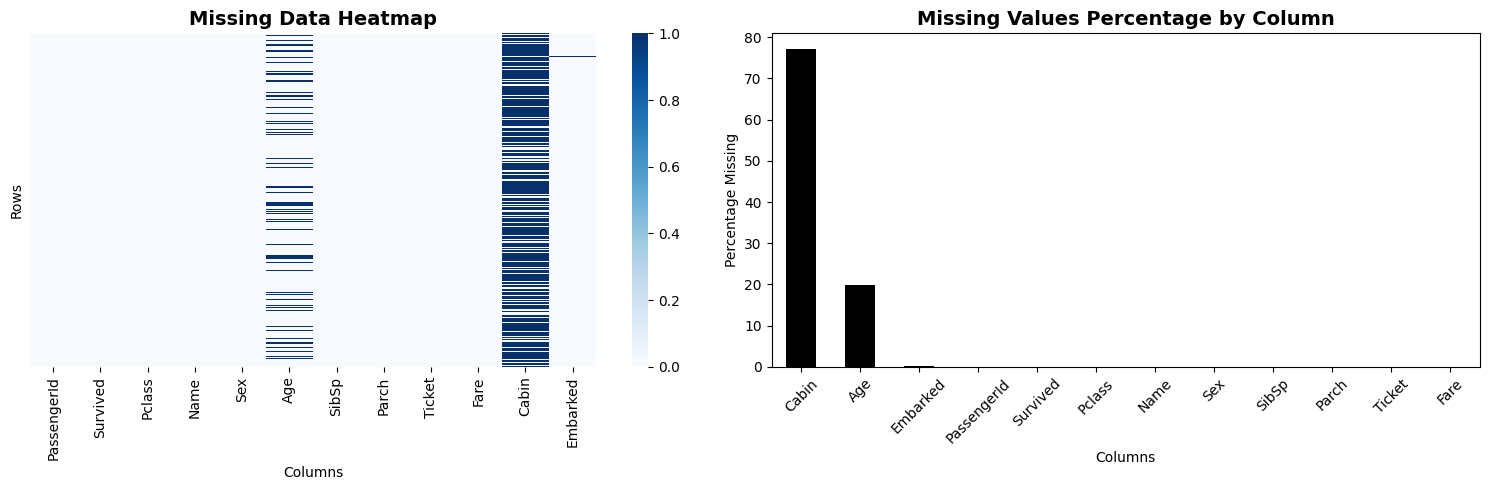


 Observations:
• Cabin has the most missing values (77%) - we'll drop this column
• Age has 20% missing - we'll impute these
• Embarked has only 2 missing - we'll fill with mode


In [184]:
missing_data = train_df.isnull().sum().sort_values(ascending=False)
missing_percent = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing Values in Training Data:")
print(missing_df)
print("\n" + "="*50)

# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(train_df.isnull(), yticklabels=False, cbar=True, cmap='Blues', ax=axes[0])
axes[0].set_title('Missing Data Heatmap', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Rows')

# Bar plot
missing_percent.plot(kind='bar', ax=axes[1], color='black')
axes[1].set_title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Columns')
axes[1].set_ylabel('Percentage Missing')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Observations:")
print("• Cabin has the most missing values (77%) - we'll drop this column")
print("• Age has 20% missing - we'll impute these")
print("• Embarked has only 2 missing - we'll fill with mode")

**3b. Data Cleaning - Handling Missing Values**

In [185]:
# Create a working copy
df = train_df.copy()
test_clean = test_df.copy()

def clean_data(data):
    """Clean data and extract cabin letter in one pass."""
    data = data.copy()

    # Fill Age with median by class and gender
    data['Age'] = data.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

    # Fill Embarked with mode
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

    # Fill Fare with median (for test set)
    if 'Fare' in data.columns:
        data['Fare'] = data['Fare'].fillna(data['Fare'].median())

    # Extract cabin letter (first character) – use 'U' for unknown
    if 'Cabin' in data.columns:
        data['CabinLetter'] = data['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'U')
        data.drop('Cabin', axis=1, inplace=True)
    else:
        data['CabinLetter'] = 'U'   # for test set if cabin missing entirely

    return data

# Clean both datasets
df = clean_data(df)
test_clean = clean_data(test_clean)

print("Data cleaning complete!")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("\nData types after cleaning:")
print(df.dtypes)

Data cleaning complete!
Remaining missing values: 0

Data types after cleaning:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
CabinLetter        str
dtype: object


**4. Exploratory Data Analysis (EDA)**


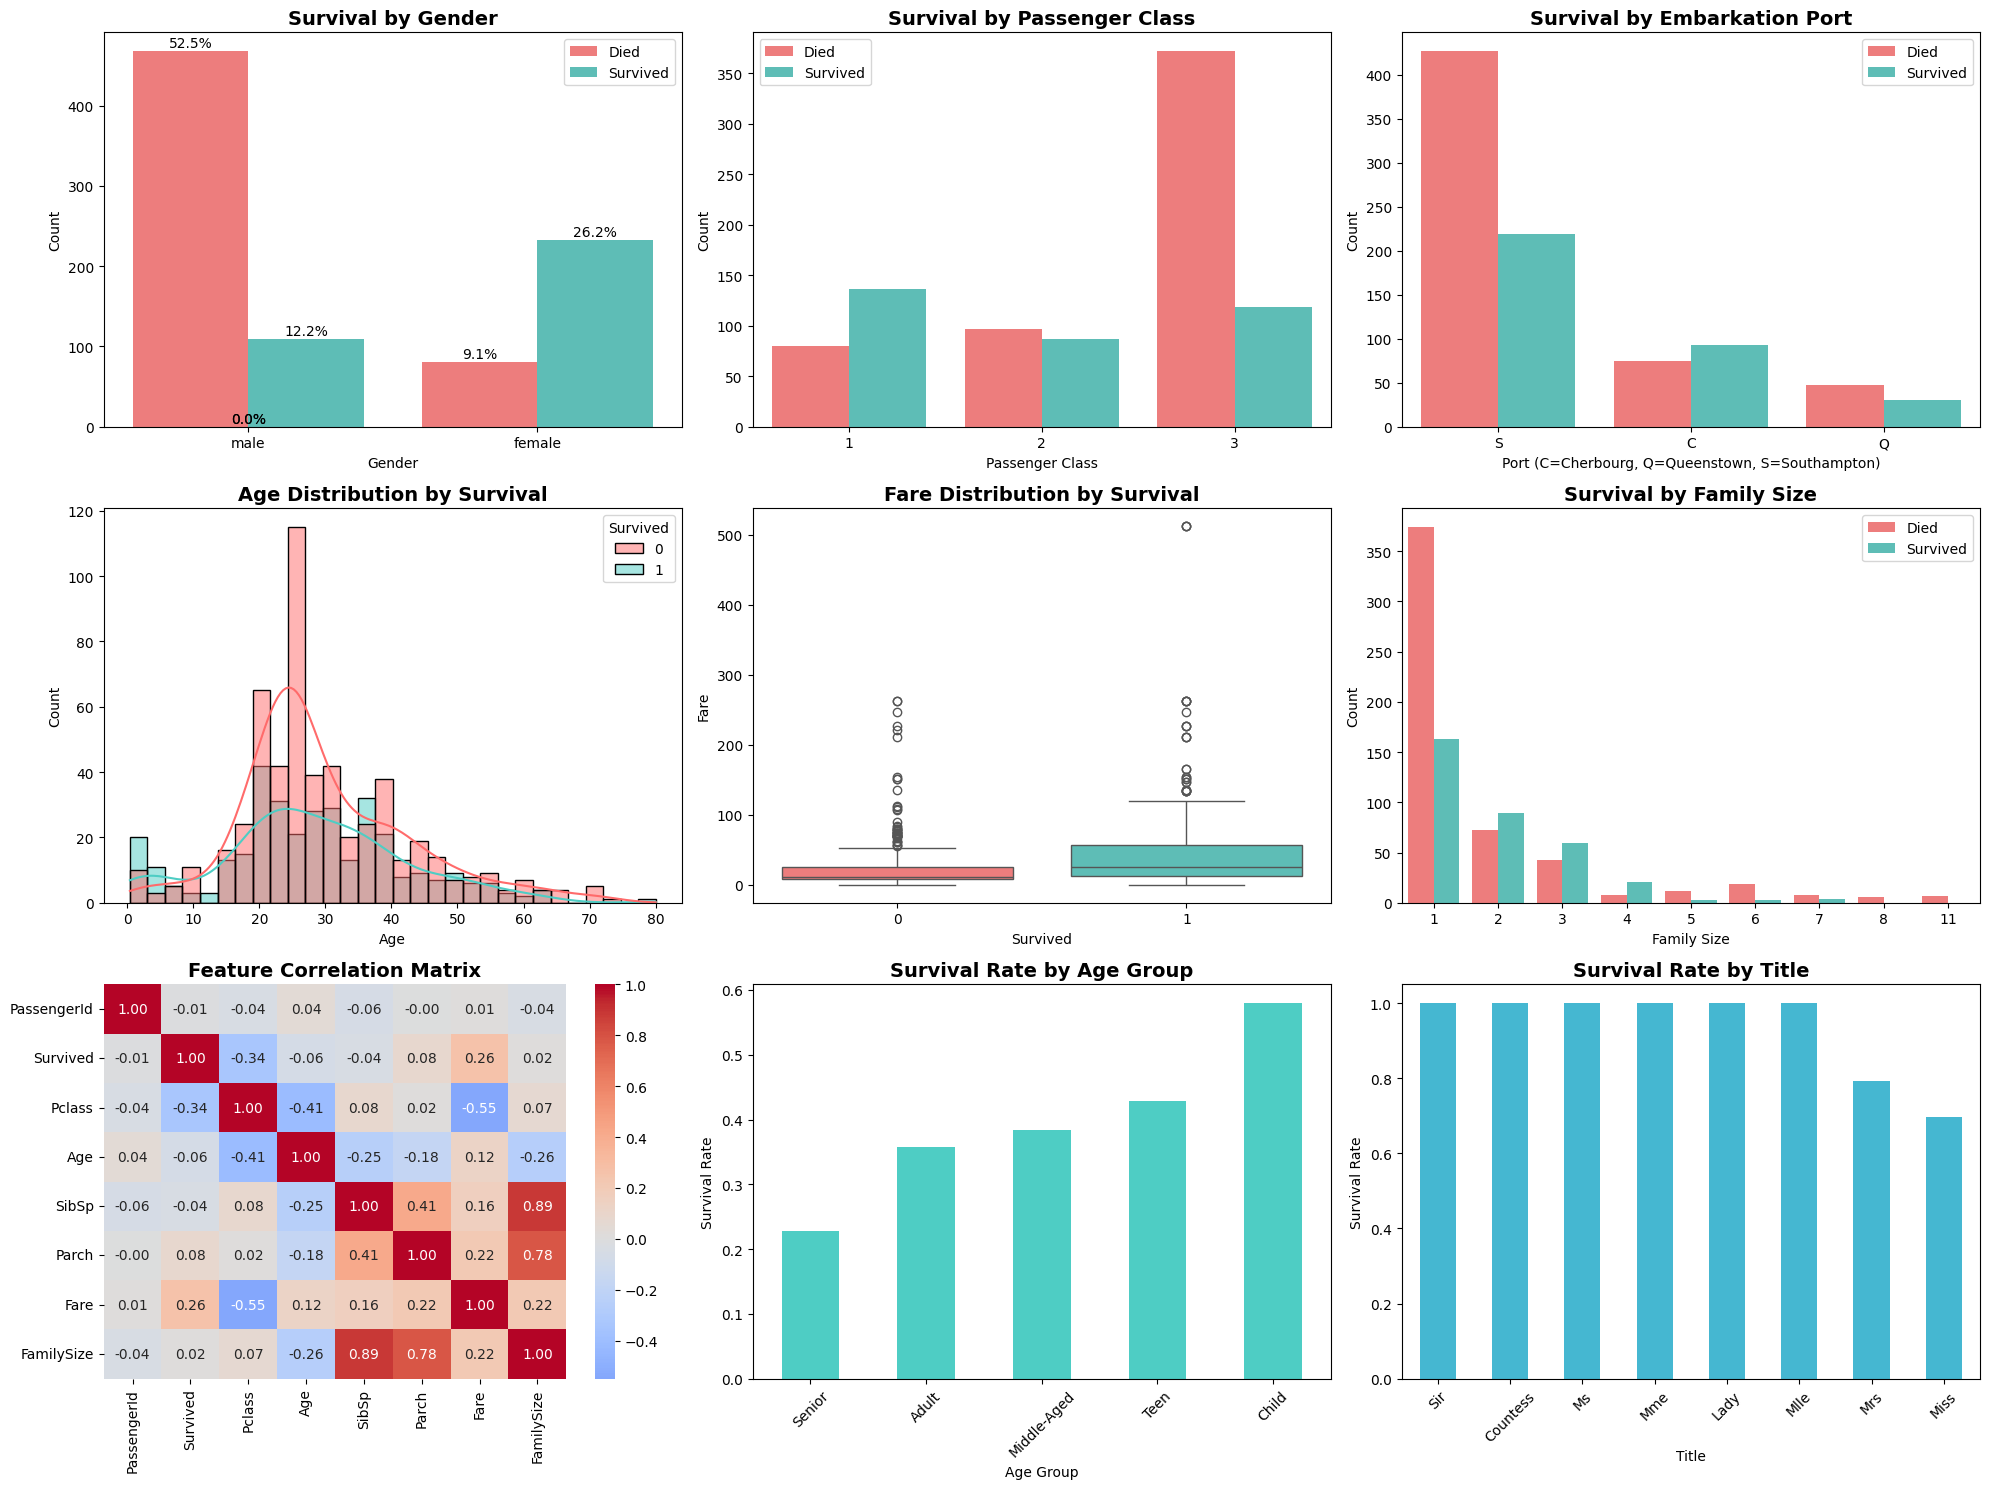


 Key Insights from EDA:
• Women survival rate: 74.2%
• Men survival rate: 18.9%
• 1st class survival rate: 63.0%
• 3rd class survival rate: 24.2%
• Children (under 12) survival rate: 57.4%


In [186]:
# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 15))

# 1. Survival by Gender
ax1 = plt.subplot(3, 3, 1)
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# Add percentages
total = len(df)
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height + 5,
             f'{height/total*100:.1f}%', ha="center")

# 2. Survival by Passenger Class
ax2 = plt.subplot(3, 3, 2)
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# 3. Survival by Embarkation Port
ax3 = plt.subplot(3, 3, 3)
sns.countplot(x='Embarked', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Embarkation Port', fontsize=14, fontweight='bold')
plt.xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# 4. Age Distribution
ax4 = plt.subplot(3, 3, 4)
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Age Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')

# 5. Fare Distribution
ax5 = plt.subplot(3, 3, 5)
sns.boxplot(x='Survived', y='Fare', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Survived')
plt.ylabel('Fare')

# 6. Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
ax6 = plt.subplot(3, 3, 6)
sns.countplot(x='FamilySize', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# 7. Correlation Heatmap
ax7 = plt.subplot(3, 3, 7)
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=ax7, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# 8. Survival Rate by Age Group
ax8 = plt.subplot(3, 3, 8)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])
survival_by_age = df.groupby('AgeGroup')['Survived'].mean().sort_values()
survival_by_age.plot(kind='bar', ax=ax8, color='#4ECDC4')
plt.title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)

# 9. Survival Rate by Title (we'll create this later, placeholder for now)
ax9 = plt.subplot(3, 3, 9)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
title_survival = df.groupby('Title')['Survived'].mean().sort_values(ascending=False).head(8)
title_survival.plot(kind='bar', ax=ax9, color='#45B7D1')
plt.title('Survival Rate by Title', fontsize=14, fontweight='bold')
plt.xlabel('Title')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('images/comprehensive_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key insights
print("\n Key Insights from EDA:")
print("="*50)
print(f"• Women survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"• Men survival rate: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"• 1st class survival rate: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"• 3rd class survival rate: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"• Children (under 12) survival rate: {df[df['Age']<12]['Survived'].mean()*100:.1f}%")

**5. Feature Engineering**

In [187]:
def create_features(df):
    """Create rich features from cleaned data."""
    df = df.copy()

    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # IsAlone
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Title from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

    # Group rare titles
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

    # Ticket group size (number of passengers sharing the same ticket)
    df['TicketGroupSize'] = df.groupby('Ticket')['PassengerId'].transform('count')

    # Fare per person
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    # IsMother (female, age > 18, and has children)
    df['IsMother'] = ((df['Sex'] == 'female') & (df['Age'] > 18) & (df['Parch'] > 0)).astype(int)

    # IsChild
    df['IsChild'] = (df['Age'] < 12).astype(int)

    # Age bands
    df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                           labels=['Child', 'Teen', 'Adult', 'MiddleAged', 'Senior'])

    # Fare bands
    df['FareBand'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'VeryHigh'], duplicates='drop')

    # Ticket prefix
    df['TicketPrefix'] = df['Ticket'].apply(lambda x: str(x).split()[0] if pd.notna(x) else 'None')

    return df

# Apply feature engineering
df = create_features(df)
test_clean = create_features(test_clean)

print("Feature engineering complete!")
print("New columns:", [col for col in df.columns if col not in train_df.columns])

Feature engineering complete!
New columns: ['CabinLetter', 'FamilySize', 'AgeGroup', 'Title', 'IsAlone', 'TicketGroupSize', 'FarePerPerson', 'IsMother', 'IsChild', 'AgeBand', 'FareBand', 'TicketPrefix']


In [188]:
# Extract cabin letter from original train data (before cleaning)
cabin_train = train_df['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'U')
cabin_test = test_df['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'U')

# Add to our cleaned dataframes
df['CabinLetter'] = cabin_train.values
test_clean['CabinLetter'] = cabin_test.values

print("Cabin letter distribution:")
print(df['CabinLetter'].value_counts())

Cabin letter distribution:
CabinLetter
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


**6. Encode Categorical Variables**

In [189]:
# List of categorical columns to encode
cat_cols = ['Sex', 'Embarked', 'Title', 'AgeBand', 'FareBand', 'CabinLetter', 'TicketPrefix']

# For columns with many unique values (like TicketPrefix), one-hot encoding may create too many features.
# We'll instead use frequency encoding or keep as is. Let's first check unique counts.
print("Unique values per categorical column:")
for col in cat_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()}")

# Strategy:
# - Sex, Embarked, Title, AgeBand, FareBand, CabinLetter: use one-hot encoding (small cardinality)
# - TicketPrefix: too many (about 500+), so we'll use frequency encoding (replace each category with its count in training)
# Alternatively, we could drop TicketPrefix if it doesn't help.

# First, frequency encode TicketPrefix using training data
ticket_counts = df['TicketPrefix'].value_counts().to_dict()
df['TicketPrefix_freq'] = df['TicketPrefix'].map(ticket_counts)
test_clean['TicketPrefix_freq'] = test_clean['TicketPrefix'].map(ticket_counts)
# Fill missing with 0 (if a new prefix appears in test)
test_clean['TicketPrefix_freq'] = test_clean['TicketPrefix_freq'].fillna(0)

# Drop original TicketPrefix
df.drop('TicketPrefix', axis=1, inplace=True)
test_clean.drop('TicketPrefix', axis=1, inplace=True)

# Now one-hot encode the remaining low-cardinality categoricals
cat_low = ['Sex', 'Embarked', 'Title', 'AgeBand', 'FareBand', 'CabinLetter']
df = pd.get_dummies(df, columns=cat_low, drop_first=True)
test_clean = pd.get_dummies(test_clean, columns=cat_low, drop_first=True)

# Ensure test has same columns as train (align)
missing_cols = set(df.columns) - set(test_clean.columns)
for col in missing_cols:
    test_clean[col] = 0
# Also drop columns that are in test but not in train (should not happen, but safe)
test_clean = test_clean[df.columns]

print("Encoding complete. New shape:", df.shape)

Unique values per categorical column:
Sex: 2
Embarked: 3
Title: 5
AgeBand: 5
FareBand: 4
CabinLetter: 9
TicketPrefix: 557
Encoding complete. New shape: (891, 39)


**7. Model Training and Hyperparameter Tuning**


In [190]:
X = df.select_dtypes(include=[np.number]).drop(['Survived'], axis=1, errors='ignore')
y = df['Survived']

# For the test set, do the same
X_test = test_clean.select_dtypes(include=[np.number])
# Align columns with X (test may have extra or missing columns)
X_test = X_test[X.columns]

print("Features shape:", X.shape)
print("Test shape:", X_test.shape)

Features shape: (891, 13)
Test shape: (418, 13)


In [191]:
# Set up cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline models (default parameters)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),  # probability=True for later voting
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

baseline_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    baseline_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: 0.7374 (+/- 0.0118)
Random Forest: 0.7587 (+/- 0.0313)
Gradient Boosting: 0.7531 (+/- 0.0204)
SVM: 0.6644 (+/- 0.0096)
XGBoost: 0.7362 (+/- 0.0321)


In [192]:
# Hyperparameter tuning for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    },

    'XGBoost' : {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }


}

best_estimators = {}
for name in models.keys():
    print(f"\n🔍 Tuning {name}...")
    grid = GridSearchCV(models[name], param_grids[name], cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X, y)
    best_estimators[name] = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.4f}")



🔍 Tuning Logistic Regression...
Best params: {'C': 10, 'solver': 'lbfgs'}
Best CV accuracy: 0.7396

🔍 Tuning Random Forest...
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.7643

🔍 Tuning Gradient Boosting...
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV accuracy: 0.7531

🔍 Tuning SVM...
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.6790

🔍 Tuning XGBoost...
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV accuracy: 0.7676


**8. Ensemble Methods**

In [196]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Voting Classifier (soft voting uses predicted probabilities)
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in best_estimators.items()],
    voting='soft'
)
voting_scores = cross_val_score(voting_clf, X, y, cv=cv, scoring='accuracy')
print(f"Voting Classifier CV accuracy: {voting_scores.mean():.4f} (+/- {voting_scores.std():.4f})")

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[(name, model) for name, model in best_estimators.items()],
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_scores = cross_val_score(stacking_clf, X, y, cv=cv, scoring='accuracy')
print(f"Stacking Classifier CV accuracy: {stacking_scores.mean():.4f} (+/- {stacking_scores.std():.4f})")

Voting Classifier CV accuracy: 0.7587 (+/- 0.0262)
Stacking Classifier CV accuracy: 0.7632 (+/- 0.0156)


**Export & Final Model Chosen: XGBoost**

In [197]:
final_model = best_estimators['XGBoost']
final_model.fit(X, y)
test_predictions = final_model.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'],
    'Survived': test_predictions
})

In [198]:
submission.to_csv('titanic_predictions.csv', index=False)
print("✅ Submission saved as 'titanic_predictions.csv'")

✅ Submission saved as 'titanic_predictions.csv'
